<a href="https://colab.research.google.com/github/sanyamtyagi229/sanyamtyagi/blob/main/heartdisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df= pd.read_csv("framingham (1).csv")

In [15]:
df.shape

(4240, 16)

In [16]:
df.head()

,Sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,male,39,4.0,No,0.0,0.0,0,0,No,195.0,106.0,70.0,26.97,80.0,77.0,0
1,female,46,2.0,No,0.0,0.0,0,0,No,250.0,121.0,81.0,28.73,95.0,76.0,0
2,male,48,1.0,Yes,20.0,0.0,0,0,No,245.0,127.5,80.0,25.34,75.0,70.0,0
3,female,61,3.0,Yes,30.0,0.0,0,1,No,225.0,150.0,95.0,28.58,65.0,103.0,1
4,female,46,3.0,Yes,23.0,0.0,0,0,No,285.0,130.0,84.0,23.10,85.0,85.0,0


In [17]:
df.tail()

,Sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,female,48,2.0,Yes,20.0,NaN,0,0,No,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,female,44,1.0,Yes,15.0,0.0,0,0,No,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,female,52,2.0,No,0.0,0.0,0,0,No,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,male,40,3.0,No,0.0,0.0,0,1,No,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,female,39,3.0,Yes,30.0,0.0,0,0,No,196.0,133.0,86.0,20.91,85.0,80.0,0


In [18]:
list(df.columns)

['Sex',
 'age',
 'education',
 'currentSmoker',
 'cigsPerDay',
 'BPMeds',
 'prevalentStroke',
 'prevalentHyp',
 'diabetes',
 'totChol',
 'sysBP',
 'diaBP',
 'BMI',
 'heartRate',
 'glucose',
 'TenYearCHD']

In [19]:
df.dtypes

,0
Sex,object
age,int64
education,float64
currentSmoker,object
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,object
totChol,float64


In [20]:
df.describe()

,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4135.000000,4211.000000,4187.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,49.580189,1.979444,9.005937,0.029615,0.005896,0.310613,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,8.572942,1.019791,11.922462,0.169544,0.076569,0.462799,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [21]:
df.isnull().sum()

,0
Sex,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


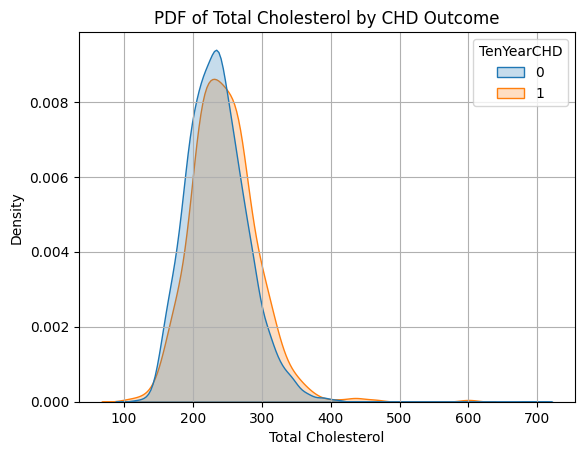

In [22]:
sns.kdeplot(data=df, x='totChol', hue='TenYearCHD', fill=True, common_norm=False)
plt.title("PDF of Total Cholesterol by CHD Outcome")
plt.xlabel("Total Cholesterol")
plt.ylabel("Density")
plt.grid(True)
plt.show()

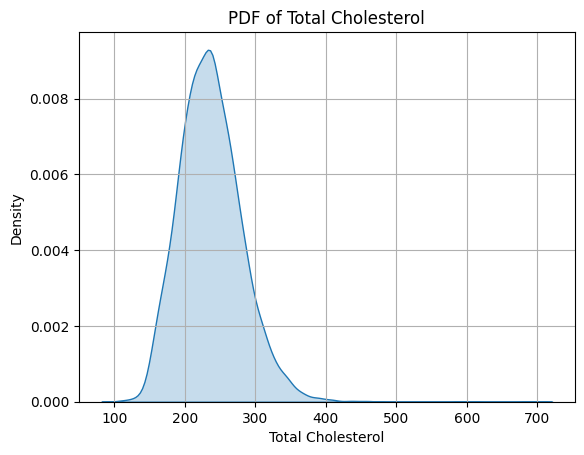

In [23]:
sns.kdeplot(data=df['totChol'], fill=True)
plt.title("PDF of Total Cholesterol")
plt.xlabel("Total Cholesterol")
plt.ylabel("Density")
plt.grid(True)
plt.show()

In [24]:
import pandas as pd

# Calculate correlation of numerical features with TenYearCHD
# Exclude 'TenYearCHD' itself from the list of features to correlate against
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('TenYearCHD')
correlation_with_chd = df[numerical_cols].corrwith(df['TenYearCHD']).sort_values(ascending=False)
print("Correlation of numerical features with TenYearCHD:")
print(correlation_with_chd)

# Calculate the mean of TenYearCHD for categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nMean TenYearCHD for categorical features:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    mean_chd = df.groupby(col)['TenYearCHD'].mean().sort_values(ascending=False)
    print(mean_chd)

Correlation of numerical features with TenYearCHD:
age                0.225408
sysBP              0.216374
prevalentHyp       0.177458
diaBP              0.145112
glucose            0.125590
BPMeds             0.087519
totChol            0.082369
BMI                0.075300
prevalentStroke    0.061823
cigsPerDay         0.057755
heartRate          0.022907
education         -0.054248
dtype: float64

Mean TenYearCHD for categorical features:

--- Sex ---
Sex
male      0.188462
female    0.124380
Name: TenYearCHD, dtype: float64

--- currentSmoker ---
currentSmoker
Yes    0.158950
No     0.144988
Name: TenYearCHD, dtype: float64

--- diabetes ---
diabetes
Yes    0.366972
No     0.146212
Name: TenYearCHD, dtype: float64


### Handling Missing Values

Before we can train a model, we need to address the missing values in the dataset. We'll fill numerical missing values with the median of their respective columns, and categorical missing values with the mode.

In [25]:
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Sex                0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


/tmp/ipykernel_523/1134764503.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


### Encoding Categorical Features

Next, we need to convert the categorical features ('Sex', 'currentSmoker', 'diabetes') into numerical representations, as machine learning models typically require numerical input. We'll use one-hot encoding for this.

In [26]:
df = pd.get_dummies(df, columns=['Sex', 'currentSmoker', 'diabetes'], drop_first=True)

display(df.head())

,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,Sex_male,currentSmoker_Yes,diabetes_Yes
0,39,4.0,0.0,0.0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,True,False,False
1,46,2.0,0.0,0.0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,False,False,False
2,48,1.0,20.0,0.0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,True,True,False
3,61,3.0,30.0,0.0,0,1,225.0,150.0,95.0,28.58,65.0,103.0,1,False,True,False
4,46,3.0,23.0,0.0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,False,True,False


### Preparing Data for Modeling

Now, we'll separate the features (X) from the target variable (y), which is 'TenYearCHD'. We'll also split the data into training and testing sets to evaluate our model's performance.

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3392, 15)
X_test shape: (848, 15)
y_train shape: (3392,)
y_test shape: (848,)


### Training a Logistic Regression Model

We will use a Logistic Regression model to predict the probability of heart disease, as it's a simple yet effective model for binary classification tasks.

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### Predicting Heart Disease Risk

Now we can use our trained model to predict the probability of heart disease for each patient in the test set. We'll then display these probabilities alongside their original data.

In [29]:

y_pred_proba = model.predict_proba(X)[:, 1]

# Create a DataFrame with original data and predicted probabilities
results_df = df.copy()
results_df['HeartDiseaseProbability'] = y_pred_proba

print("Patient-wise heart disease risk probabilities:")
display(results_df[['age', 'Sex_male', 'currentSmoker_Yes', 'diabetes_Yes', 'HeartDiseaseProbability']].head())

Patient-wise heart disease risk probabilities:


,age,Sex_male,currentSmoker_Yes,diabetes_Yes,HeartDiseaseProbability
0,39,True,False,False,0.044646
1,46,False,False,False,0.049072
2,48,True,True,False,0.145710
3,61,False,True,False,0.366923
4,46,False,True,False,0.098731
